In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from varclushi import VarClusHi

abt = pd.read_parquet('C:/Users/twluc/frame/01_data/03_abt/major/abt.parquet')

# input variables: season window, drop rolling, targets, and all away-team columns
def select_features(include_awt=False):
    num = abt.select_dtypes('number').columns
    return [c for c in num
            if 'rolling' not in c and not c.startswith('t_')
            and (include_awt or not c.startswith('awt'))
            and abt[c].nunique() > 1]

features = select_features()
len(features)

89

In [2]:
def varclus_groups(cols, maxeigval2=1, maxclus=None, min_rs=0.5):
    vc = VarClusHi(abt[cols].dropna(), maxeigval2=maxeigval2, maxclus=maxclus)
    vc.varclus()
    rsquare = vc.rsquare

    kept = []
    loose = []
    for cluster in rsquare['Cluster'].unique():
        members = rsquare[rsquare['Cluster'] == cluster].sort_values('RS_Own', ascending=False)
        keep = members[members['RS_Own'] >= min_rs]
        loose += members[members['RS_Own'] < min_rs]['Variable'].tolist()
        if not keep.empty:
            kept.append(keep)

    kept.sort(key=len, reverse=True)

    reps = []
    for group in kept:
        rep = group.iloc[0]['Variable']
        reps.append(rep)
        print(rep)
        for _, row in group.iloc[1:].iterrows():
            print(f"    {row['Variable']:46s} {row['RS_Own']:.2f}")
        print()

    print(f'loose (RS_Own < {min_rs}):')
    for col in sorted(loose):
        print('   ', col)

    group_corr = abt[reps].corr(method='spearman')
    plt.figure(figsize=(len(reps) * 0.6 + 3, len(reps) * 0.5 + 3))
    sns.heatmap(group_corr, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, vmin=-1, vmax=1, square=True, cbar=False)
    plt.title(f'representatives  (maxeigval2={maxeigval2}, min_rs={min_rs}, {len(reps)} groups)')
    plt.tight_layout()
    plt.show()


hmt_season_goals_diff_avg
    hmt_season_points_avg                          0.84
    hmt_season_impl_win_avg                        0.83
    hmt_season_impl_points_avg                     0.83
    hmt_season_wins_ratio                          0.80
    hmt_season_impl_loss_avg                       0.80
    hmt_season_goals_for_avg                       0.79
    hmt_season_shots_on_target_diff_avg            0.77
    hmt_season_shots_on_target_for_avg             0.72
    hmt_elo                                        0.71
    hmt_home_season_goals_diff_avg                 0.71
    hmt_season_losses_ratio                        0.67
    hmt_season_goals_for_le1_ratio                 0.66
    hmt_home_season_points_avg                     0.66
    hmt_home_season_goals_for_avg                  0.65
    hmt_season_shots_for_avg                       0.62
    hmt_season_goals_for_le2_ratio                 0.62
    hmt_home_season_shots_on_target_for_avg        0.59
    hmt_season_goals_f

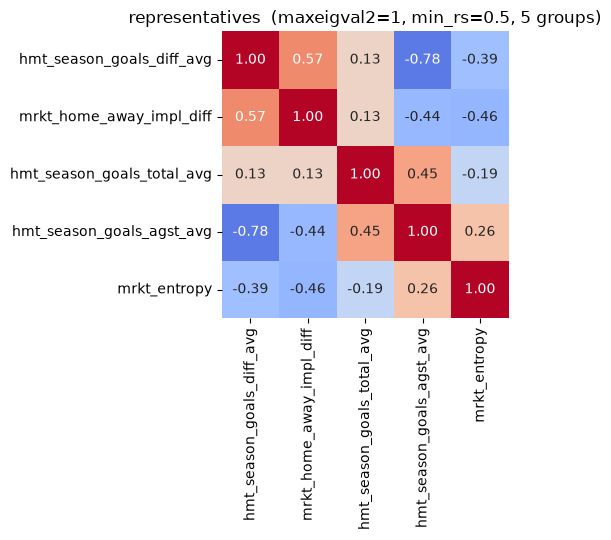

In [3]:
varclus_groups(features, maxclus=5)